## Configuration and Setup

This cell sets up the core configuration for the retrieval-augmented generation (RAG) pipeline:

- Defines paths to the FAISS indexes and precomputed embedding files.
- Sets the decoding option used during answer generation (`"A"` for deterministic / beam search, `"B"` for sampling).
- Imports essential libraries, including:
  - PyTorch and FAISS for computation and similarity search.
  - Transformers and CLIP for multimodal processing.
  - SentenceTransformers for embedding support.
- Automatically selects GPU if available, otherwise defaults to CPU.


In [1]:
# Paths to precomputed FAISS indexes and embeddings
INDEX_DIR = "data/RAG/Version_V2/indexes"
EMBEDDINGS_PATH = "data/RAG/Version_V2/embeddings/all_papers.embeddings.pkl"
TEXT_INDEX_PATH = f"{INDEX_DIR}/text.index.faiss"
IMAGE_INDEX_PATH = f"{INDEX_DIR}/image.index.faiss"

# Decoding strategy: "A" for deterministic (beam search), "B" for controlled sampling
SELECT_OPTION = "A"  # Choose "A" or "B" to set generation mode
# (Option A = beam search for factual consistency; Option B = nucleus sampling for varied phrasing)

# Import required libraries
import os, time, pickle
import numpy as np
import torch
import faiss 
from transformers import AutoProcessor, AutoModelForVision2Seq, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer
from transformers import CLIPModel, CLIPProcessor
from PIL import Image

# Device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## Load Embeddings, Indexes, and Query Models

This step performs the following key tasks:

- **Load precomputed embeddings** from a pickle file (`all_papers.embeddings.pkl`).
- **Separate records by type** into text and image groups, ensuring each aligns with its corresponding FAISS index.
- **Verify embedding dimensions**:
  - 384-dim vectors for text
  - 896-dim (ViT/CLIP format) for image figures and tables
- **Load FAISS indexes** for fast similarity search over text and image chunks.
- **Load embedding models for query encoding**:
  - `sentence-transformers/all-MiniLM-L6-v2` for text.
  - OpenAI CLIP model (`ViT-B/32`) for image-based queries.

These components power retrieval in later stages.


In [2]:
# Load precomputed embeddings
with open(EMBEDDINGS_PATH, "rb") as f:
    all_records = pickle.load(f)
print(f"Loaded {len(all_records)} embedded chunk records from pickle.")

# Separate records by type (text vs image) for use with respective indexes
text_records = [rec for rec in all_records if rec["type"] in {"paragraph", "text", "equation"}]
image_records = [rec for rec in all_records if rec["type"] in {"figure", "table"}]
print(f"Text records: {len(text_records)} | Image records: {len(image_records)}")

# Verify embedding dimensions (expected 384 for text, 896 for image)
if text_records:
    print("Sample text embedding length:", len(text_records[0]["embedding"]))
if image_records:
    print("Sample image embedding length:", len(image_records[0]["embedding"]))

# Load FAISS indexes
index_text = faiss.read_index(TEXT_INDEX_PATH)
index_image = faiss.read_index(IMAGE_INDEX_PATH)
print("FAISS indexes loaded (text & image).")

# Load query embedding models for retrieval
# SentenceTransformer for text query embedding (384-dim)
text_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
# CLIP model and processor for image query embedding (512-dim image features, compatible with ViT-B/32)
clip_model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)
# Move CLIP model to the same device (for efficiency); text_model can stay on CPU if GPU memory is limited
clip_model = clip_model.to(device)
print("Query embedding models loaded (MiniLM for text, CLIP for image).")


Loaded 2330 embedded chunk records from pickle.
Text records: 1960 | Image records: 370
Sample text embedding length: 384
Sample image embedding length: 896
FAISS indexes loaded (text & image).


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Query embedding models loaded (MiniLM for text, CLIP for image).


## Load the LLaVA 1.5-7B Model in 4-bit Quantized Mode

This step loads the vision-language model (LLaVA 1.5-7B) with efficient 4-bit quantization using `bitsandbytes`, reducing memory usage without sacrificing much performance.

Key operations:
- Define the HuggingFace model ID for LLaVA (`llava-hf/llava-1.5-7b-hf`)
- Set up quantization with `BitsAndBytesConfig`, using FP16 compute (better GPU performance)
- Load:
  - The **AutoProcessor** to tokenize and format inputs (text + image)
  - The **AutoModelForVision2Seq** for generation
- Apply automatic GPU/CPU layer placement and switch the model to evaluation mode.

This prepares LLaVA for answering multimodal queries.


In [3]:
# Load LLaVA 1.5-7B model and processor in 4-bit mode
model_id = "llava-hf/llava-1.5-7b-hf"

# Configure 4-bit quantization (using bitsandbytes)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16  # use FP16 compute for better performance on GPU
)

# Load the processor for LLaVA 
processor = AutoProcessor.from_pretrained(model_id)

# Load the LLaVA model with quantization
model = AutoModelForVision2Seq.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    quantization_config=bnb_config,
    device_map="auto"    # automatically place layers on GPU/CPU as available
)
model.eval()  
print("LLaVA model loaded in 4-bit mode.")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/home/mt3846/envTorch124/lib/python3.10/site-packages/transformers/models/auto/modeling_auto.py:2291: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

LLaVA model loaded in 4-bit mode.


## Construct Multimodal Inputs from Retrieved Text and Figures

This helper function `build_model_inputs()` prepares inputs for the LLaVA model by retrieving and formatting relevant content from the knowledge base.

Steps involved:
- **Retrieve top-k text and image hits** using FAISS similarity search.
- **Truncate and label text passages**, preserving page and section metadata.
- **Insert image blocks** with captions; images are loaded if file paths exist, otherwise a fallback note is added.
- **System prompt includes** task guidance for grounded and cite-aware answering.
- **Compose a single user message** containing images followed by combined text context and the question.
- **Tokenize and format** the conversation for LLaVA’s multimodal interface.

This step creates rich, structured input that blends visual and textual evidence for high-quality question answering.


In [4]:
# Prompt construction helper
MAX_TEXT_LEN = 1200  # max characters from each text chunk to include

def build_model_inputs(query: str, k_text: int = 3, k_image: int = 2):
    """Retrieve relevant text/images for the query and build multimodal model inputs."""
    # Retrieve top-k text and image results from FAISS indexes
    text_hits, image_hits = retrieve_text(query, k=k_text), retrieve_image(query, k=k_image)
    
    # Prepare text blocks with citations
    text_blocks = []
    for i, hit in enumerate(text_hits, start=1):
        content = hit.get("content") or ""
        if len(content) > MAX_TEXT_LEN:
            content = content[:MAX_TEXT_LEN] + " ..."
        page = hit.get("page", "?")
        section = hit.get("section", "?")
        text_block = f"[TEXT #{i} | page {page} | section {section}]\n{content}"
        text_blocks.append(text_block)
    
    # Prepare image (figure/table) blocks with captions
    image_block_count = 0
    multimodal_blocks = []  # will hold dicts of type "text" or "image"
    for i, hit in enumerate(image_hits, start=1):
        caption = hit.get("content") or ""
        page = hit.get("page", "?")
        section = hit.get("section", "?")
        image_block_count += 1
        # Caption text block for the figure/table
        multimodal_blocks.append({
            "type": "text",
            "text": f"[FIGURE #{i} | page {page} | section {section}]\nCaption: {caption}"
        })
        # Actual image block if file path is available
        img_path = hit.get("image_path")
        if img_path and os.path.exists(img_path):
            multimodal_blocks.append({
                "type": "image",
                "image": img_path
            })
        else:
            # If image file not found, insert a note instead of an image block
            multimodal_blocks.append({
                "type": "text",
                "text": "(Image file not found for this figure)"
            })
    
    # Combine all text blocks (from text_hits) into one context string
    context_text = "\n\n".join(text_blocks)
    
    # Define task guidance (system prompt) for the model
    task_guidance = (
        "You are reading an academic paper with text and figures. "
        "Use only the provided content to answer the question. If information is missing, say so.\n\n"
        "When answering:\n"
        "1) Be concise and factual.\n"
        "2) Cite evidence like [TEXT #2] or [FIGURE #1] after claims.\n"
        "3) Explain how the evidence supports your answer."
    )
    
    # Construct the conversation with one user turn including images and text
    conversation = [{
        "role": "user",
        "content": (
            # First, placeholders for each retrieved image:
            [{"type": "image"} for _ in range(image_block_count)] + 
            # Then one text entry containing guidance, context, and question:
            [{
                "type": "text",
                "text": (
                    task_guidance + "\n\n" +
                    (context_text + "\n\n" if context_text else "") +
                    f"Question: {query}\nAnswer:"
                )
            }]
        )
    }]
    
    # Apply chat template and tokenize inputs
    prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
    model_inputs = processor(text=prompt, images=None if image_block_count == 0 else [
        Image.open(block["image"]).convert("RGB") for block in multimodal_blocks if block["type"] == "image"
    ], return_tensors="pt")
    model_inputs = model_inputs.to(device)  # move inputs to GPU if available
    
    # Get special token IDs for generation (eos/pad) from tokenizer
    tok = processor.tokenizer
    eos_id = tok.eos_token_id
    pad_id = tok.pad_token_id if tok.pad_token_id is not None else eos_id
    
    return model_inputs, eos_id, pad_id


## Retrieval Functions for Text and Image Context

These functions search the FAISS indexes to retrieve the most relevant text passages and figures for a given query.

- `retrieve_text(query, k)`:  
  - Encodes the query using a 384-dimensional SentenceTransformer.
  - Performs a FAISS cosine similarity search against the text index.
  - Returns metadata including rank, score, section info, and text content.

- `retrieve_image(query, k)`:  
  - Uses CLIP to embed the query in a 512-dim vision-language space, combined with a 384-dim text embedding.
  - Concatenates both into an 896-dimensional query vector.
  - Searches the image FAISS index for matching figures/tables.
  - Returns metadata including score, section info, caption, and image path.

These retrieval methods ensure that both textual and visual evidence can be matched and cited during multimodal reasoning.


In [5]:
# Retrieval helper functions

def retrieve_text(query: str, k: int = 5):
    """Search the text FAISS index for top-k relevant text chunks for the query."""
    # Embed query to 384-dim text vector (normalize for cosine similarity)
    query_vec = text_model.encode([query], convert_to_numpy=True)
    query_vec = query_vec / np.linalg.norm(query_vec, axis=1, keepdims=True)  # normalize
    query_vec = query_vec.astype('float32')
    # FAISS search
    distances, indices = index_text.search(query_vec, k)
    hits = []
    for rank, idx in enumerate(indices[0]):
        record = text_records[idx]
        hits.append({
            "rank": rank,
            "score": float(distances[0][rank]),
            "id": record["id"],
            "type": record["type"],
            "page": record.get("metadata", {}).get("page"),
            "section": record.get("metadata", {}).get("section"),
            "content": record.get("content", "")
        })
    return hits

def retrieve_image(query: str, k: int = 5):
    """Search the image FAISS index for top-k relevant figure/table chunks for the query."""
    # Embed query into 512-d CLIP text space and 384-d text space, then concatenate
    clip_inputs = clip_processor(text=[query], images=None, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        clip_text_feat = clip_model.get_text_features(**clip_inputs)
    clip_vec = clip_text_feat.cpu().numpy()
    clip_vec = clip_vec / np.linalg.norm(clip_vec, axis=1, keepdims=True)  # normalize 512-d
    text_vec = text_model.encode([query], convert_to_numpy=True)
    text_vec = text_vec / np.linalg.norm(text_vec, axis=1, keepdims=True)  # normalize 384-d
    # Concatenate 512 + 384 -> 896-d query vector
    combined_vec = np.hstack([clip_vec, text_vec]).astype('float32')
    # FAISS search in image index
    distances, indices = index_image.search(combined_vec, k)
    hits = []
    for rank, idx in enumerate(indices[0]):
        record = image_records[idx]
        hits.append({
            "rank": rank,
            "score": float(distances[0][rank]),
            "id": record["id"],
            "type": record["type"],
            "page": record.get("metadata", {}).get("page"),
            "section": record.get("metadata", {}).get("section"),
            "image_path": record.get("metadata", {}).get("image_path"),  # path to image file
            "content": record.get("content", "")  # caption text if available
        })
    return hits


## Answer Generation with LLaVA

This section defines how answers are generated for user queries using the LLaVA model. It includes:

- **`get_gen_kwargs(eos_id, pad_id)`**:  
  Returns decoding configuration based on the selected mode:
  - **Option A**: Deterministic beam search for consistency.
  - **Option B**: Top-p (nucleus) sampling for diverse phrasing.

- **`clean_answer(text)`**:  
  Post-processes model output to:
  - Normalize internal citations (e.g., `[TEXT #2]`, `[FIGURE #1]`).
  - Strip external URLs and unrelated bracketed references.
  - Return clean, human-readable answers.

- **`generate_answer(query)`**:  
  - Retrieves relevant multimodal context.
  - Constructs model input and invokes generation.
  - Measures latency.
  - Extracts and cleans the generated response.

This modular design supports flexible decoding while ensuring factual grounding and clear output formatting.


In [6]:
# Generation configuration and answer function

def get_gen_kwargs(eos_id, pad_id):
    """Return generation parameters based on SELECT_OPTION (A=beam search, B=top-p sampling)."""
    if SELECT_OPTION.upper() == "A":
        # Deterministic Beam Search parameters
        return {
            "max_new_tokens": 480,
            "min_new_tokens": 120,
            "num_beams": 3,
            "length_penalty": 1.0,
            "early_stopping": False,
            "eos_token_id": eos_id,
            "pad_token_id": pad_id,
            "no_repeat_ngram_size": 3
        }
    else:
        # Controlled Sampling (Top-p nucleus sampling) parameters
        return {
            "max_new_tokens": 480,
            "min_new_tokens": 120,
            "do_sample": True,
            "temperature": 0.4,
            "top_p": 0.92,
            "repetition_penalty": 1.1,
            "eos_token_id": eos_id,
            "pad_token_id": pad_id,
            "no_repeat_ngram_size": 3
        }

import re
def clean_answer(text: str) -> str:
    """Post-process the model output text for cleaner presentation."""
    # Standardize citation bracket spacing (e.g., ensure format "[TEXT #1]")
    text = re.sub(r"\[TEXT\s*#\s*(\d+)\]", r"[TEXT #\1]", text, flags=re.IGNORECASE)
    text = re.sub(r"\[FIG(?:URE)?\s*#\s*(\d+)\]", r"[FIGURE #\1]", text, flags=re.IGNORECASE)
    # Remove any purely numeric citations or stray brackets (e.g., [1], [23])
    text = re.sub(r"\[(\d+)\]", "", text)
    # Remove external URLs if any (we only want internal citations)
    text = re.sub(r"https?://\S+", "", text)
    return text.strip()

def generate_answer(query: str):
    """Retrieve context for the query, run the LLaVA model to generate an answer, and return the answer and latency."""
    # Build model input with retrieved context
    model_inputs, eos_id, pad_id = build_model_inputs(query, k_text=3, k_image=2)
    gen_kwargs = get_gen_kwargs(eos_id, pad_id)
    # Generate answer using the model
    start_time = time.time()
    with torch.no_grad():
        output_ids = model.generate(**model_inputs, **gen_kwargs)
    latency = time.time() - start_time
    # Decode the generated tokens to text
    output_text = processor.tokenizer.decode(output_ids[0], skip_special_tokens=True)
    # Extract the assistant's answer portion (after the prompt "Answer:")
    if "Answer:" in output_text:
        output_text = output_text.split("Answer:")[-1]
    # Remove any leading role indicator or colon
    output_text = output_text.replace("ASSISTANT:", "").replace("Assistant:", "")
    answer = clean_answer(output_text)
    return answer, latency


## Multimodal QA Evaluation on Sample Paper Questions

This final section evaluates the RAG + LLaVA pipeline using a set of predefined technical questions across five recent LLM research papers.

- **`paper_questions`**:  
  A list of tuples, each containing:
  - Paper title
  - A detailed, domain-specific question related to the paper’s core contributions

- **Evaluation Loop**:
  - Iterates through each question
  - Formats the query with paper context
  - Uses the `generate_answer()` function to produce an answer
  - Logs the output and generation latency

- **Report Generation**:
  - Answers are formatted into Markdown
  - All results are saved to `rag_eval_results1.md` for easy review or sharing

This structured QA run provides qualitative insights into how well the model retrieves and synthesizes multimodal evidence for complex academic queries.


In [7]:
# Define sample paper questions for evaluation
paper_questions = [
    ("LLM in a Flash (ACL'24)",
     "How does the system enable long-context inference on memory-limited devices using NVMe, and what are the key scheduling/prefetching ideas?"),
    ("FlashAttention-2 (2023)",
     "What kernel-level changes make FA-2 faster than FA-1, and how do tiling/parallelization reduce memory traffic?"),
    ("vLLM: PagedAttention (2023)",
     "Explain how PagedAttention reduces memory fragmentation and improves throughput during batched decoding."),
    ("Speculative Decoding (Leviathan et al., 2023)",
     "Summarize the draft-verify process and the acceptance criterion; what governs speedup vs. quality?"),
    ("H2O: Efficient LLM Inference (2023)",
     "Why is KV-cache eviction in H2O not equivalent to Belady's cache policy, and what heuristics does H2O use?")
]


# Build metadata header
# ---------------------------
config_header = f"""
# Multimodal RAG Evaluation Report
Generated on: {time.strftime('%Y-%m-%d %H:%M:%S')}

## Model & Modes
- **Model:** LLaVA 1.5 - 7B (4-bit quantized)
- **Generation Mode:** {"Top-p Sampling (Option B)" if SELECT_OPTION.upper()=="B" else "Beam Search (Option A)"}

## Generation Hyperparameters
"""

# Extract actual generation hyperparameters (dummy pad/eos OK)
tmp_gen_params = get_gen_kwargs(0, 0)
for k, v in tmp_gen_params.items():
    config_header += f"- **{k}**: {v}\n"

config_header += """
## Retrieval Settings
- Top-k Text Retrieval: 3
- Top-k Image Retrieval: 2
- Text Encoder: sentence-transformers/all-MiniLM-L6-v2
- Image Encoder: CLIP ViT-B/32
- FAISS Index Type: Flat (L2-normalized)

---

"""


# Run evaluation loop
# ---------------------------
report_lines = []
for idx, (paper, question) in enumerate(paper_questions, start=1):
    query = f"[Paper: {paper}] {question}"

    # Generate answer + measure latency
    answer, latency = generate_answer(query)

    print(f"\n=== [{idx}] {paper} ===")
    print(f"Q: {question}\n")
    print(f"A: {answer}\n(Generated in {latency:.2f} seconds)\n")

    report_lines.append(
        f"### {idx}. {paper}\n"
        f"**Q:** {question}\n\n"
        f"**A:** {answer}\n\n"
        f"_Generated in {latency:.2f}s_\n"
    )

# Save to Markdown file
# ---------------------------
md_path = "rag_eval_results22.md"
full_report = config_header + "\n---\n".join(report_lines)

with open(md_path, "w", encoding="utf-8") as f:
    f.write(full_report)

print(f"Results saved to {md_path}")
print("Evaluation complete.")



=== [1] LLM in a Flash (ACL'24) ===
Q: How does the system enable long-context inference on memory-limited devices using NVMe, and what are the key scheduling/prefetching ideas?

A: The paper presents a novel approach to enabling long- context inference on resource-restricted devices, specifically focusing on memory limitations. The proposed solution involves utilizing the available flash memory to store the model weights and employing efficient scheduling and prefetching techniques. The key ideas include:

1. Windowing: This technique involves dividing the input data into smaller chunks and processing them in a sliding window fashion. By doing so, it reduces the amount of data that needs to be loaded from flash memory at any given time, thus decreasing the overall latency experienced by the system.
 
2. Row-Column Bundling: This method involves bundling rows and columns of data together before loading them into memory. This allows for more efficient use of available memory and reduce


=== Q1 ===
Latency: 81.41s
Retrieval Score: 0.411
Answer Match: 0.393
OVERALL QUALITY: 0.404

=== Q2 ===
Latency: 55.84s
Retrieval Score: 0.444
Answer Match: 0.131
OVERALL QUALITY: 0.319

=== Q3 ===
Latency: 47.53s
Retrieval Score: 0.522
Answer Match: 0.128
OVERALL QUALITY: 0.364

=== Q4 ===
Latency: 57.93s
Retrieval Score: 0.456
Answer Match: 0.413
OVERALL QUALITY: 0.438

=== Q5 ===
Latency: 52.51s
Retrieval Score: 0.405
Answer Match: 0.170
OVERALL QUALITY: 0.311


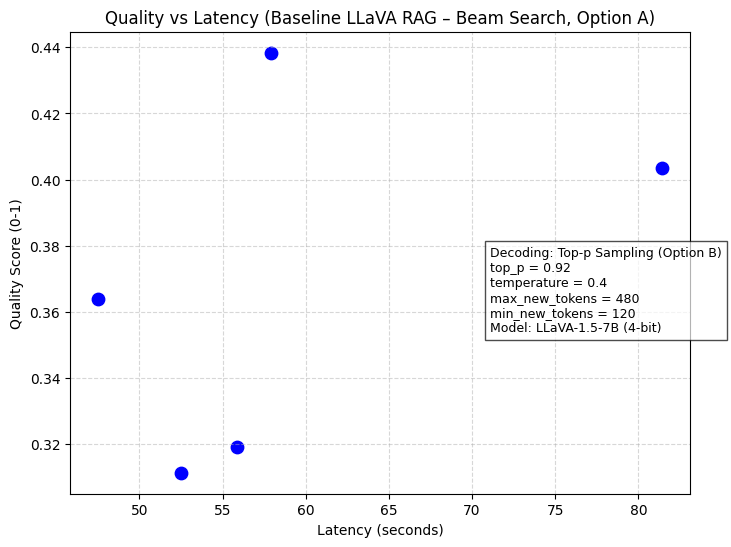

Saved plot to results/quality_vs_latency_baseline1.png


In [9]:
# ============================================================
# QUALITY SCORING FOR BASELINE RAG (Retrieval + Answer Match)
# ============================================================

import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


def clean(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# ------------------------------------------------------------
# 1. Retrieval Grounding Score (keyword overlap)
# ------------------------------------------------------------
def retrieval_grounding_score(answer, retrieved_docs):
    """
    Score = fraction of answer keywords that appear in retrieved docs.
    """
    ans_tok = set(clean(answer).split())
    doc_text = clean(" ".join(retrieved_docs))
    doc_tok = set(doc_text.split())

    if len(ans_tok) == 0:
        return 0.0

    overlap = ans_tok & doc_tok
    return len(overlap) / len(ans_tok)


# ------------------------------------------------------------
# 2. Answer-Paper Match Score (semantic similarity)
# ------------------------------------------------------------
def answer_match_score(answer, question):
    """
    Uses TF-IDF cosine similarity as a simple semantic metric.
    """
    docs = [clean(answer), clean(question)]
    vec = TfidfVectorizer().fit_transform(docs)
    sim = cosine_similarity(vec[0], vec[1])[0][0]
    return float(sim)


# ------------------------------------------------------------
# 3. Wrapper to compute both quality components
# ------------------------------------------------------------
def compute_quality(answer, question, retrieved_docs):
    ret_score = retrieval_grounding_score(answer, retrieved_docs)
    ans_score = answer_match_score(answer, question)

    # Weighted avg (you can change this)
    overall = 0.6 * ret_score + 0.4 * ans_score
    return ret_score, ans_score, overall



# ============================================================
# RUN QUALITY EVALUATION ON YOUR RESULTS
# ============================================================

quality_results = []

for idx, (paper, question) in enumerate(paper_questions, start=1):

    query = f"[Paper: {paper}] {question}"

    # ---- Retrieve context (text only for scoring) ----
    text_hits = retrieve_text(query, k=3)
    retrieved_chunks = [hit["content"] for hit in text_hits]

    # ---- Generate answer & latency ----
    answer, latency = generate_answer(query)

    # ---- Compute quality metrics ----
    ret_score, ans_score, overall = compute_quality(answer, question, retrieved_chunks)

    quality_results.append({
        "question": question,
        "latency": latency,
        "retrieval_score": ret_score,
        "answer_score": ans_score,
        "overall_score": overall
    })

    print(f"\n=== Q{idx} ===")
    print(f"Latency: {latency:.2f}s")
    print(f"Retrieval Score: {ret_score:.3f}")
    print(f"Answer Match: {ans_score:.3f}")
    print(f"OVERALL QUALITY: {overall:.3f}")


# ============================================================
# PLOT: Quality vs Latency (Top-p Sampling, Option B)
# ============================================================

import matplotlib.pyplot as plt

latencies = [x["latency"] for x in quality_results]
qualities = [x["overall_score"] for x in quality_results]

plt.figure(figsize=(8,6))
plt.scatter(latencies, qualities, color="blue", s=80)

plt.title("Quality vs Latency (Baseline LLaVA RAG – Beam Search, Option A)")
plt.xlabel("Latency (seconds)")
plt.ylabel("Quality Score (0-1)")

# Annotation box with decoding settings
textstr = (
    "Decoding: Top-p Sampling (Option B)\n"
    "top_p = 0.92\n"
    "temperature = 0.4\n"
    "max_new_tokens = 480\n"
    "min_new_tokens = 120\n"
    "Model: LLaVA-1.5-7B (4-bit)"
)

plt.gcf().text(
    0.65, 0.38, textstr,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='black')
)

plt.grid(True, linestyle="--", alpha=0.5)

plt.savefig("results/quality_vs_latency_baseline1.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot to results/quality_vs_latency_baseline1.png")
